#### 多臂老虎机完整实现：Bernoulli Bandit + ε-Greedy

随机生成了一个 10 臂伯努利老虎机
获奖概率最大的拉杆为 1 号，其获奖概率为 0.7203

ε = 0.01
最终累计懊悔： 920.8069049180626

每根拉杆被选择的次数：
[6.000e+00 8.000e+00 6.000e+00 3.000e+00 6.000e+00 7.000e+00 4.000e+00
 9.000e+00 1.000e+01 4.941e+03]

每根拉杆最终的期望奖励估计：
[0.33333333 0.5        0.         0.         0.33333333 0.
 0.25       0.11111111 0.4        0.54442421]

算法最终最看好的拉杆： 9


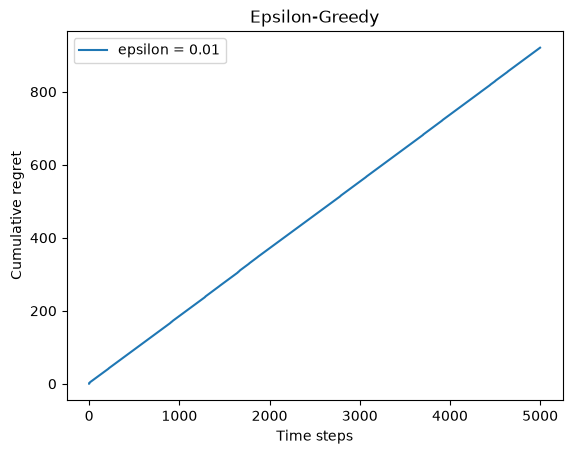

In [1]:
# 多臂老虎机完整实现：Bernoulli Bandit + ε-Greedy

import numpy as np
import matplotlib.pyplot as plt


class BernoulliBandit:
    def __init__(self, K):
        self.probs = np.random.uniform(size=K)
        self.best_idx = np.argmax(self.probs)
        self.best_prob = self.probs[self.best_idx]
        self.K = K

    def step(self, k):
        if np.random.rand() < self.probs[k]:
            return 1
        else:
            return 0


class Solver:
    def __init__(self, bandit):
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K)
        self.regret = 0.
        self.actions = []
        self.regrets = []

    def update_regret(self, k):
        self.regret += (self.bandit.best_prob - self.bandit.probs[k])
        self.regrets.append(self.regret)

    def run_one_step(self):

        raise NotImplementedError

    def run(self, num_steps):
        for _ in range(num_steps):
            k = self.run_one_step()
            self.counts[k] += 1
            self.actions.append(k)
            self.update_regret(k)


class EpsilonGreedy(Solver):
    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        super(EpsilonGreedy, self).__init__(bandit)
        self.epsilon = epsilon
        self.estimates = np.array([init_prob] * self.bandit.K)

    def run_one_step(self):
        if np.random.random() < self.epsilon:
            k = np.random.randint(0, self.bandit.K)
        else:
            k = np.argmax(self.estimates)

        r = self.bandit.step(k)
        self.estimates[k] += (1. / (self.counts[k] + 1) * (r - self.estimates[k]))

        return k


np.random.seed(1)
K = 10
bandit_10_arm = BernoulliBandit(K)
print("随机生成了一个 %d 臂伯努利老虎机" % K)
print("获奖概率最大的拉杆为 %d 号，其获奖概率为 %.4f" % (bandit_10_arm.best_idx, bandit_10_arm.best_prob))


epsilon = 0.01
epsilon_greedy_solver = EpsilonGreedy(
    bandit=bandit_10_arm,
    epsilon=epsilon,
    init_prob=1.0
)


num_steps = 5000
epsilon_greedy_solver.run(num_steps)


print("\nε =", epsilon)
print("最终累计懊悔：", epsilon_greedy_solver.regret)
print("\n每根拉杆被选择的次数：")
print(epsilon_greedy_solver.counts)
print("\n每根拉杆最终的期望奖励估计：")
print(epsilon_greedy_solver.estimates)
print("\n算法最终最看好的拉杆：", np.argmax(epsilon_greedy_solver.estimates))


plt.plot(
    range(num_steps),
    epsilon_greedy_solver.regrets,
    label="epsilon = %.2f" % epsilon
)

plt.xlabel("Time steps")

plt.ylabel("Cumulative regret")

plt.title("Epsilon-Greedy")

plt.legend()

plt.show()